In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
import os
print(os.getcwd())


C:\Users\User


In [5]:
df = pd.read_csv('Life Expectancy Data.csv')
df.head()


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

In [7]:
df.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

In [8]:
df = df.dropna(subset=['Life expectancy'])

KeyError: ['Life expectancy']

In [ ]:
df.columns.tolist()


In [ ]:
df.columns = df.columns.str.strip()
df.columns.tolist()

In [ ]:
df = df.dropna(subset=['Life expectancy'])

In [ ]:
df = df.fillna(df.mean(numeric_only=True))

In [ ]:
print(df.isnull().sum())

In [ ]:
yearly = df.groupby('Year')['Life expectancy'].mean()

plt.figure(figsize=(10, 5))
plt.plot(yearly.index, yearly.values, color='#7F77DD', linewidth=2)
plt.title('Global average life expectancy over time')
plt.xlabel('Year')
plt.ylabel('Life expectancy (years)')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 5))

for status, group in df.groupby('Status'):
    yearly = group.groupby('Year')['Life expectancy'].mean()
    plt.plot(yearly.index, yearly.values, linewidth=2, label=status)

plt.title('Life expectancy: developed vs developing countries')
plt.xlabel('Year')
plt.ylabel('Life expectancy (years)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
df.to_csv('clean_health.csv', index=False)
print('Saved!')

In [ ]:
import sqlite3
conn = sqlite3.connect('health.db')
df.to_sql('life_expectancy', conn, if_exists='replace', index=False)
print('Database created!')  # confirms it worked


In [ ]:
result = pd.read_sql_query("""
    SELECT Country,
           ROUND(AVG([Life expectancy]), 1) AS avg_life_exp
    FROM life_expectancy
    GROUP BY Country
    ORDER BY avg_life_exp DESC
    LIMIT 10
""", conn)

# display the result as a table right inside the notebook
result

In [ ]:
result = pd.read_sql_query("""
    SELECT Country,
           ROUND(AVG([Life expectancy]), 1) AS avg_life_exp
    FROM life_expectancy
    GROUP BY Country
    ORDER BY avg_life_exp DESC
    LIMIT 20

""", conn)

# display the result as a table right inside the notebook
result

In [9]:
result2 = pd.read_sql_query("""
    SELECT Status,
            ROUND(AVG([Life expectancy]), 1) AS avg_life_exp,
            COUNT(DISTINCT Country)       AS num_countries
        FROM life_expectancy
        GROUP BY Status
    """, conn)

NameError: name 'conn' is not defined

In [10]:
df = pd.read_csv('Life Expectancy Data.csv')


In [11]:
df.columns = df.columns.str.strip()

In [12]:
df = df.dropna(subset=['Life expectancy'])

# fill remaining missing numeric values with each column's mean
df = df.fillna(df.mean(numeric_only=True))

In [13]:
df.to_csv('clean_health.csv', index=False)

print('Saved!')  # confirms the file was created

Saved!


In [14]:
import sqlite3

In [15]:
import sqlite3  # built-in Python library for creating and querying SQL databases

# creates a local database file called health.db (creates it if it doesn't exist)
conn = sqlite3.connect('health.db')

# writes your cleaned DataFrame into the database as a table named 'life_expectancy'
# if_exists='replace' overwrites the table if it already exists from a previous run
# index=False skips writing row numbers as a column
df.to_sql('life_expectancy', conn, if_exists='replace', index=False)

print('Database created!')  # confirms it worked

Database created!


In [16]:
result2 = pd.read_sql_query("""
    SELECT Status,
           ROUND(AVG([Life expectancy]), 1) AS avg_life_exp,
           COUNT(DISTINCT Country)          AS num_countries
    FROM life_expectancy
    GROUP BY Status
""", conn)

result2

,Status,avg_life_exp,num_countries
0,Developed,79.2,32
1,Developing,67.1,151


In [17]:
df['Status'].unique()

<StringArray>
['Developing', 'Developed']
Length: 2, dtype: str

In [18]:
df['Status'].nunique()

2

In [19]:
result1 = pd.read_sql_query("""
    SELECT Country,
           Year,
           ROUND(GDP, 2)        AS gdp,
           [Life expectancy]    AS life_exp
    FROM life_expectancy
    WHERE GDP > 0
    ORDER BY gdp DESC
    LIMIT 20
""", conn)

result1

,Country,Year,gdp,life_exp
0,Luxembourg,2014,119172.74,81.7
1,Luxembourg,2011,115761.58,88.0
2,Luxembourg,2008,114293.84,80.0
3,Luxembourg,2013,113751.85,81.4
4,Luxembourg,2006,89739.71,79.4
5,Qatar,2012,88564.82,77.8
6,Switzerland,2011,87998.44,82.6
7,Norway,2010,87646.75,81.0
8,Qatar,2014,86852.71,78.1
9,Qatar,2011,85948.75,77.5


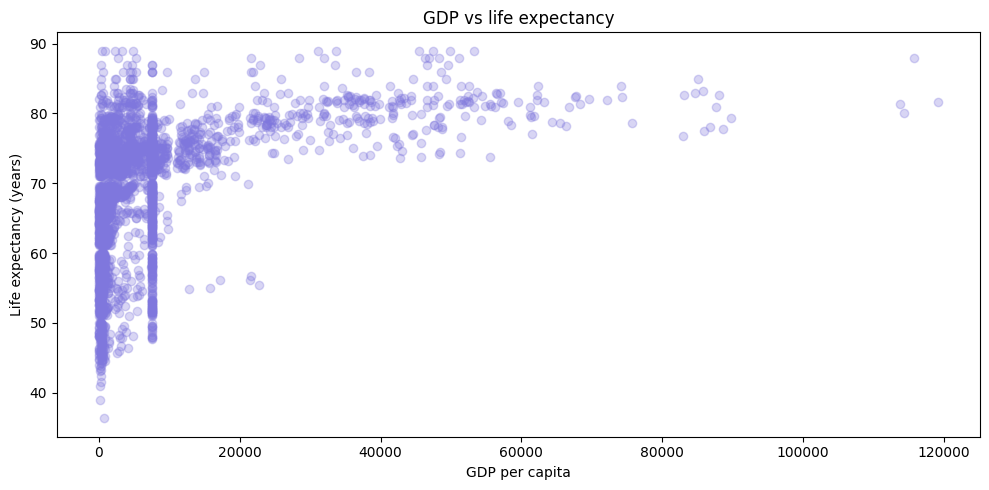

In [20]:
plt.figure(figsize=(10, 5))
plt.scatter(df['GDP'], df['Life expectancy'], alpha=0.3, color='#7F77DD')

# alpha=0.3 makes dots semi-transparent so overlapping points are visible
plt.title('GDP vs life expectancy')
plt.xlabel('GDP per capita')
plt.ylabel('Life expectancy (years)')
plt.tight_layout()
plt.show()

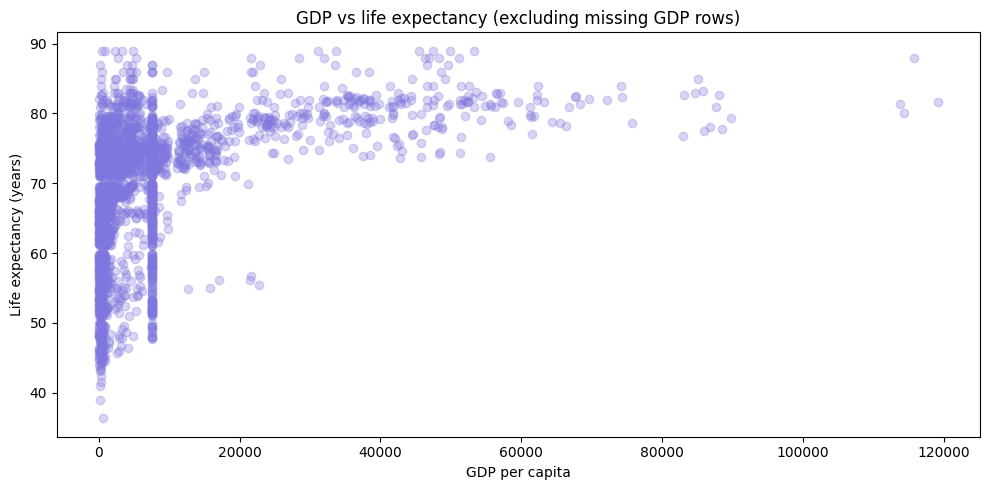

In [21]:
df_gdp = df[df['GDP'] > 10]

plt.figure(figsize=(10, 5))

# each dot represents one country-year combination
# alpha=0.3 makes dots semi-transparent so dense areas are still readable
plt.scatter(df_gdp['GDP'], df_gdp['Life expectancy'], alpha=0.3, color='#7F77DD')

plt.title('GDP vs life expectancy (excluding missing GDP rows)')
plt.xlabel('GDP per capita')
plt.ylabel('Life expectancy (years)')
plt.tight_layout()
plt.show()

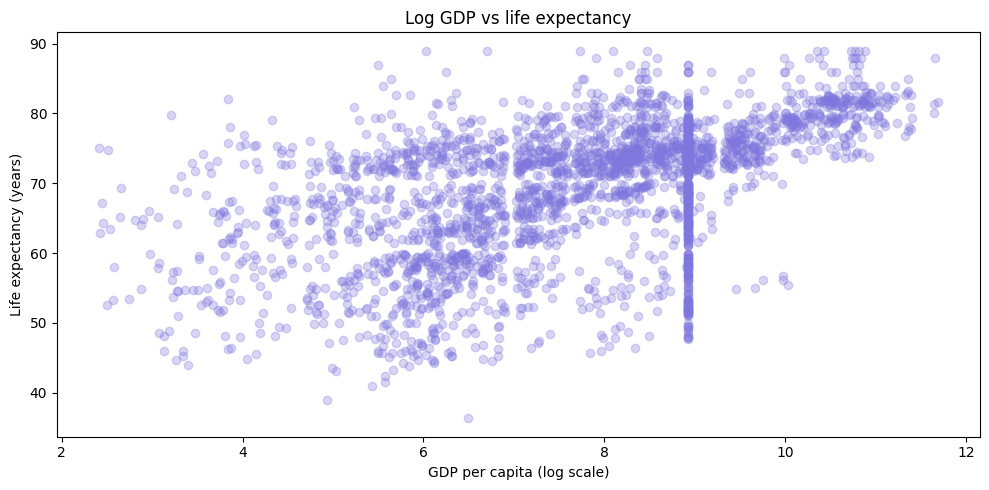

In [22]:
import numpy as np  # numpy is a math library, we need it for the log transformation

# np.log() transforms GDP using logarithm, which compresses the huge range
# this makes the pattern much easier to see when data is heavily skewed
df_gdp = df[df['GDP'] > 10].copy()
df_gdp['log_GDP'] = np.log(df_gdp['GDP'])

plt.figure(figsize=(10, 5))
plt.scatter(df_gdp['log_GDP'], df_gdp['Life expectancy'], alpha=0.3, color='#7F77DD')

plt.title('Log GDP vs life expectancy')
plt.xlabel('GDP per capita (log scale)')
plt.ylabel('Life expectancy (years)')
plt.tight_layout()
plt.show()

In [23]:
df[df['Country'].isin(['Canada', 'France', 'Greece', 'Israel'])][['Country', 'Status']].drop_duplicates()

,Country,Status
496,Canada,Developing
930,France,Developing
1026,Greece,Developing
1266,Israel,Developing


In [24]:
fix_countries = ['Canada', 'France', 'Greece', 'Israel']

# overwrite their Status value with 'Developed'
df.loc[df['Country'].isin(fix_countries), 'Status'] = 'Developed'

# verify the fix worked
df[df['Country'].isin(fix_countries)][['Country', 'Status']].drop_duplicates()


,Country,Status
496,Canada,Developed
930,France,Developed
1026,Greece,Developed
1266,Israel,Developed


In [25]:
df.to_csv('clean_health.csv', index=False)
print('Saved!')

Saved!
